In [1]:
import nltk
from nltk.sentiment import SentimentIntensityAnalyzer
import pandas as pd
import numpy as np
import subprocess
import os
from datetime import datetime, timedelta, time, date
import datetime
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns
from textblob import TextBlob
from nltk.sentiment import SentimentIntensityAnalyzer
import speech_recognition as sr
from pydub import AudioSegment
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import nltk
from wordcloud import WordCloud
from collections import Counter
import re
import seaborn as sns
import matplotlib.pyplot as plt

c:\Users\Jonny Villareal\AppData\Local\Programs\Python\Python312\Lib\site-packages\pydub\utils.py:170: RuntimeWarning: Couldn't find ffmpeg or avconv - defaulting to ffmpeg, but may not work
  warn("Couldn't find ffmpeg or avconv - defaulting to ffmpeg, but may not work", RuntimeWarning)


In [2]:
df_iri = pd.read_excel(
    "C:/Users/Jonny Villareal/OneDrive - Gmovil SAS/Escritorio/Jonny/Control 2026/control_regularidad.xlsx",
    sheet_name="IRI_Etapa1",
    engine="openpyxl"
)

df_iri.head()

,IdIRI,Estado,Fecha Viaje,F. Inicio DP,F. Cierre DP,Fuente,Servicio,IdViaje,ViajeLinea,Coche,...,Dif Hora Real y Teor,Intervalo Regulado,Viaje Regular,Enviado en VacÃ­o,Ruta Calcula IRI,Nodo,Cantidad,Evidencia,Ruta_comercial,Mes
0,85262879,Validado,2026-02-01,2026-02-04,2026-02-10 23:59:59,URBANO,CE06B0015,2,1,15,...,-1.08,150000000,1,0,1,52845.0,1.0,NaN,740,febrero
1,85263393,Validado,2026-02-01,2026-02-04,2026-02-10 23:59:59,URBANO,CE08F0008,8,7,7,...,0.03,200000000,1,0,1,74036.0,1.0,NaN,806,febrero
2,85264191,Validado,2026-02-01,2026-02-04,2026-02-10 23:59:59,URBANO,CE0B10003,13,12,3,...,6.50,200000000,1,0,1,58634.0,1.0,NaN,5-4,febrero
3,85263986,Validado,2026-02-01,2026-02-04,2026-02-10 23:59:59,ALIMENTACION,CE0A60012,18,17,2,...,0.12,150000000,1,0,1,73713.0,1.0,NaN,16-14 Aeropuerto,febrero
4,85264502,Validado,2026-02-01,2026-02-04,2026-02-10 23:59:59,URBANO,CE0D50006,12,6,6,...,3.00,300000000,1,0,1,58149.0,1.0,NaN,12,febrero


In [3]:
df_iri = df_iri[
    df_iri["Hora Real"].notna() & (df_iri["Hora Real"] != "")
]

df_iri.head()

,IdIRI,Estado,Fecha Viaje,F. Inicio DP,F. Cierre DP,Fuente,Servicio,IdViaje,ViajeLinea,Coche,...,Dif Hora Real y Teor,Intervalo Regulado,Viaje Regular,Enviado en VacÃ­o,Ruta Calcula IRI,Nodo,Cantidad,Evidencia,Ruta_comercial,Mes
0,85262879,Validado,2026-02-01,2026-02-04,2026-02-10 23:59:59,URBANO,CE06B0015,2,1,15,...,-1.08,150000000,1,0,1,52845.0,1.0,NaN,740,febrero
1,85263393,Validado,2026-02-01,2026-02-04,2026-02-10 23:59:59,URBANO,CE08F0008,8,7,7,...,0.03,200000000,1,0,1,74036.0,1.0,NaN,806,febrero
2,85264191,Validado,2026-02-01,2026-02-04,2026-02-10 23:59:59,URBANO,CE0B10003,13,12,3,...,6.50,200000000,1,0,1,58634.0,1.0,NaN,5-4,febrero
3,85263986,Validado,2026-02-01,2026-02-04,2026-02-10 23:59:59,ALIMENTACION,CE0A60012,18,17,2,...,0.12,150000000,1,0,1,73713.0,1.0,NaN,16-14 Aeropuerto,febrero
4,85264502,Validado,2026-02-01,2026-02-04,2026-02-10 23:59:59,URBANO,CE0D50006,12,6,6,...,3.00,300000000,1,0,1,58149.0,1.0,NaN,12,febrero


In [4]:
df_iri["franja"] = df_iri["Hora Real"].astype(str).str.split(":").str[0]

df_iri.head()

,IdIRI,Estado,Fecha Viaje,F. Inicio DP,F. Cierre DP,Fuente,Servicio,IdViaje,ViajeLinea,Coche,...,Intervalo Regulado,Viaje Regular,Enviado en VacÃ­o,Ruta Calcula IRI,Nodo,Cantidad,Evidencia,Ruta_comercial,Mes,franja
0,85262879,Validado,2026-02-01,2026-02-04,2026-02-10 23:59:59,URBANO,CE06B0015,2,1,15,...,150000000,1,0,1,52845.0,1.0,NaN,740,febrero,07
1,85263393,Validado,2026-02-01,2026-02-04,2026-02-10 23:59:59,URBANO,CE08F0008,8,7,7,...,200000000,1,0,1,74036.0,1.0,NaN,806,febrero,17
2,85264191,Validado,2026-02-01,2026-02-04,2026-02-10 23:59:59,URBANO,CE0B10003,13,12,3,...,200000000,1,0,1,58634.0,1.0,NaN,5-4,febrero,13
3,85263986,Validado,2026-02-01,2026-02-04,2026-02-10 23:59:59,ALIMENTACION,CE0A60012,18,17,2,...,150000000,1,0,1,73713.0,1.0,NaN,16-14 Aeropuerto,febrero,11
4,85264502,Validado,2026-02-01,2026-02-04,2026-02-10 23:59:59,URBANO,CE0D50006,12,6,6,...,300000000,1,0,1,58149.0,1.0,NaN,12,febrero,20


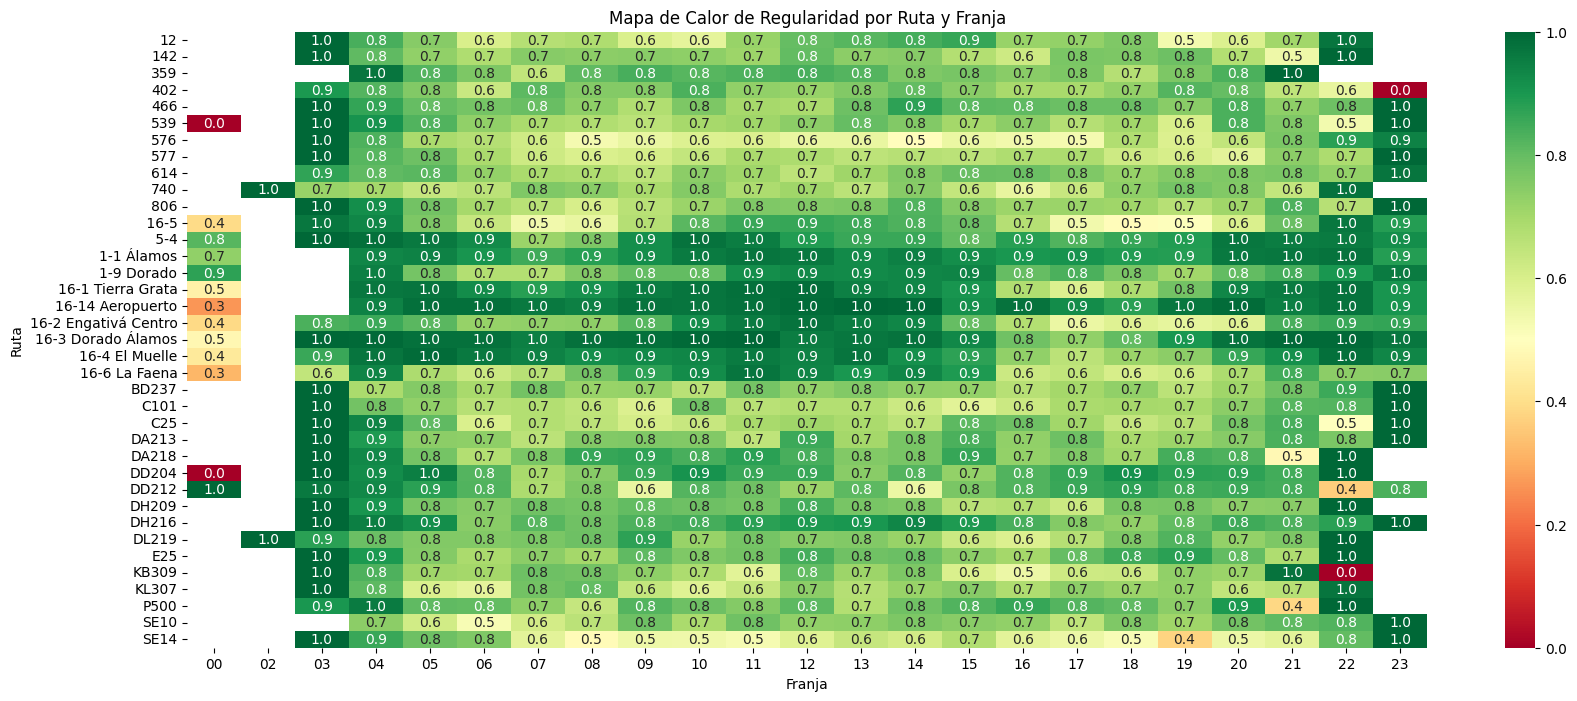

In [5]:
pivot = df_iri.pivot_table(
    index="Ruta_comercial",
    columns="franja",
    values="Viaje Regular",
    aggfunc="mean"
)

plt.figure(figsize=(20,8))

sns.heatmap(
    pivot,
    annot=True,
    cmap="RdYlGn",
    fmt=".1f"
)

plt.title("Mapa de Calor de Regularidad por Ruta y Franja")
plt.xlabel("Franja")
plt.ylabel("Ruta")

plt.show()

Retraso acumulado

In [6]:
df_iri["hora_real"] = df_iri['Hora Real']

df_iri.head()

,IdIRI,Estado,Fecha Viaje,F. Inicio DP,F. Cierre DP,Fuente,Servicio,IdViaje,ViajeLinea,Coche,...,Viaje Regular,Enviado en VacÃ­o,Ruta Calcula IRI,Nodo,Cantidad,Evidencia,Ruta_comercial,Mes,franja,hora_real
0,85262879,Validado,2026-02-01,2026-02-04,2026-02-10 23:59:59,URBANO,CE06B0015,2,1,15,...,1,0,1,52845.0,1.0,NaN,740,febrero,07,07:38:55
1,85263393,Validado,2026-02-01,2026-02-04,2026-02-10 23:59:59,URBANO,CE08F0008,8,7,7,...,1,0,1,74036.0,1.0,NaN,806,febrero,17,17:50:32
2,85264191,Validado,2026-02-01,2026-02-04,2026-02-10 23:59:59,URBANO,CE0B10003,13,12,3,...,1,0,1,58634.0,1.0,NaN,5-4,febrero,13,13:08:30
3,85263986,Validado,2026-02-01,2026-02-04,2026-02-10 23:59:59,ALIMENTACION,CE0A60012,18,17,2,...,1,0,1,73713.0,1.0,NaN,16-14 Aeropuerto,febrero,11,11:36:07
4,85264502,Validado,2026-02-01,2026-02-04,2026-02-10 23:59:59,URBANO,CE0D50006,12,6,6,...,1,0,1,58149.0,1.0,NaN,12,febrero,20,20:00:30


In [7]:
df_iri["hora_programada"] = (
    df_iri["Hora TeÃ³rica"]
    .astype(str)
    .str.extract(r'(\d{1,2}:\d{2}:\d{2})')
)

df_iri.head()

,IdIRI,Estado,Fecha Viaje,F. Inicio DP,F. Cierre DP,Fuente,Servicio,IdViaje,ViajeLinea,Coche,...,Enviado en VacÃ­o,Ruta Calcula IRI,Nodo,Cantidad,Evidencia,Ruta_comercial,Mes,franja,hora_real,hora_programada
0,85262879,Validado,2026-02-01,2026-02-04,2026-02-10 23:59:59,URBANO,CE06B0015,2,1,15,...,0,1,52845.0,1.0,NaN,740,febrero,07,07:38:55,07:40:00
1,85263393,Validado,2026-02-01,2026-02-04,2026-02-10 23:59:59,URBANO,CE08F0008,8,7,7,...,0,1,74036.0,1.0,NaN,806,febrero,17,17:50:32,17:50:30
2,85264191,Validado,2026-02-01,2026-02-04,2026-02-10 23:59:59,URBANO,CE0B10003,13,12,3,...,0,1,58634.0,1.0,NaN,5-4,febrero,13,13:08:30,13:02:00
3,85263986,Validado,2026-02-01,2026-02-04,2026-02-10 23:59:59,ALIMENTACION,CE0A60012,18,17,2,...,0,1,73713.0,1.0,NaN,16-14 Aeropuerto,febrero,11,11:36:07,11:36:00
4,85264502,Validado,2026-02-01,2026-02-04,2026-02-10 23:59:59,URBANO,CE0D50006,12,6,6,...,0,1,58149.0,1.0,NaN,12,febrero,20,20:00:30,19:57:30


In [8]:
df_iri["hora_real"] = pd.to_datetime(df_iri["hora_real"], format="%H:%M:%S", errors="coerce")
df_iri["hora_programada"] = pd.to_datetime(df_iri["hora_programada"], format="%H:%M:%S", errors="coerce")

In [9]:
df_iri["retraso_min"] = (
    df_iri["hora_real"] - df_iri["hora_programada"]
).dt.total_seconds()/60

df_iri.head()

,IdIRI,Estado,Fecha Viaje,F. Inicio DP,F. Cierre DP,Fuente,Servicio,IdViaje,ViajeLinea,Coche,...,Ruta Calcula IRI,Nodo,Cantidad,Evidencia,Ruta_comercial,Mes,franja,hora_real,hora_programada,retraso_min
0,85262879,Validado,2026-02-01,2026-02-04,2026-02-10 23:59:59,URBANO,CE06B0015,2,1,15,...,1,52845.0,1.0,NaN,740,febrero,07,1900-01-01 07:38:55,1900-01-01 07:40:00,-1.083333
1,85263393,Validado,2026-02-01,2026-02-04,2026-02-10 23:59:59,URBANO,CE08F0008,8,7,7,...,1,74036.0,1.0,NaN,806,febrero,17,1900-01-01 17:50:32,1900-01-01 17:50:30,0.033333
2,85264191,Validado,2026-02-01,2026-02-04,2026-02-10 23:59:59,URBANO,CE0B10003,13,12,3,...,1,58634.0,1.0,NaN,5-4,febrero,13,1900-01-01 13:08:30,1900-01-01 13:02:00,6.500000
3,85263986,Validado,2026-02-01,2026-02-04,2026-02-10 23:59:59,ALIMENTACION,CE0A60012,18,17,2,...,1,73713.0,1.0,NaN,16-14 Aeropuerto,febrero,11,1900-01-01 11:36:07,1900-01-01 11:36:00,0.116667
4,85264502,Validado,2026-02-01,2026-02-04,2026-02-10 23:59:59,URBANO,CE0D50006,12,6,6,...,1,58149.0,1.0,NaN,12,febrero,20,1900-01-01 20:00:30,1900-01-01 19:57:30,3.000000


In [10]:
contagio = df_iri.groupby("Ruta_comercial")["retraso_min"].mean().sort_values(ascending=False)

In [11]:
estabilidad = df_iri.groupby("Ruta_comercial")["Viaje Regular"].agg([
    "mean",
    "std"
]).reset_index()

estabilidad["indice_estabilidad"] = (
    1 / estabilidad["std"]
)

estabilidad.head()

,Ruta_comercial,mean,std,indice_estabilidad
0,12,0.715929,0.451049,2.217052
1,142,0.730971,0.443528,2.254650
2,359,0.785304,0.410677,2.435002
3,402,0.751469,0.432225,2.313611
4,466,0.781888,0.413017,2.421209


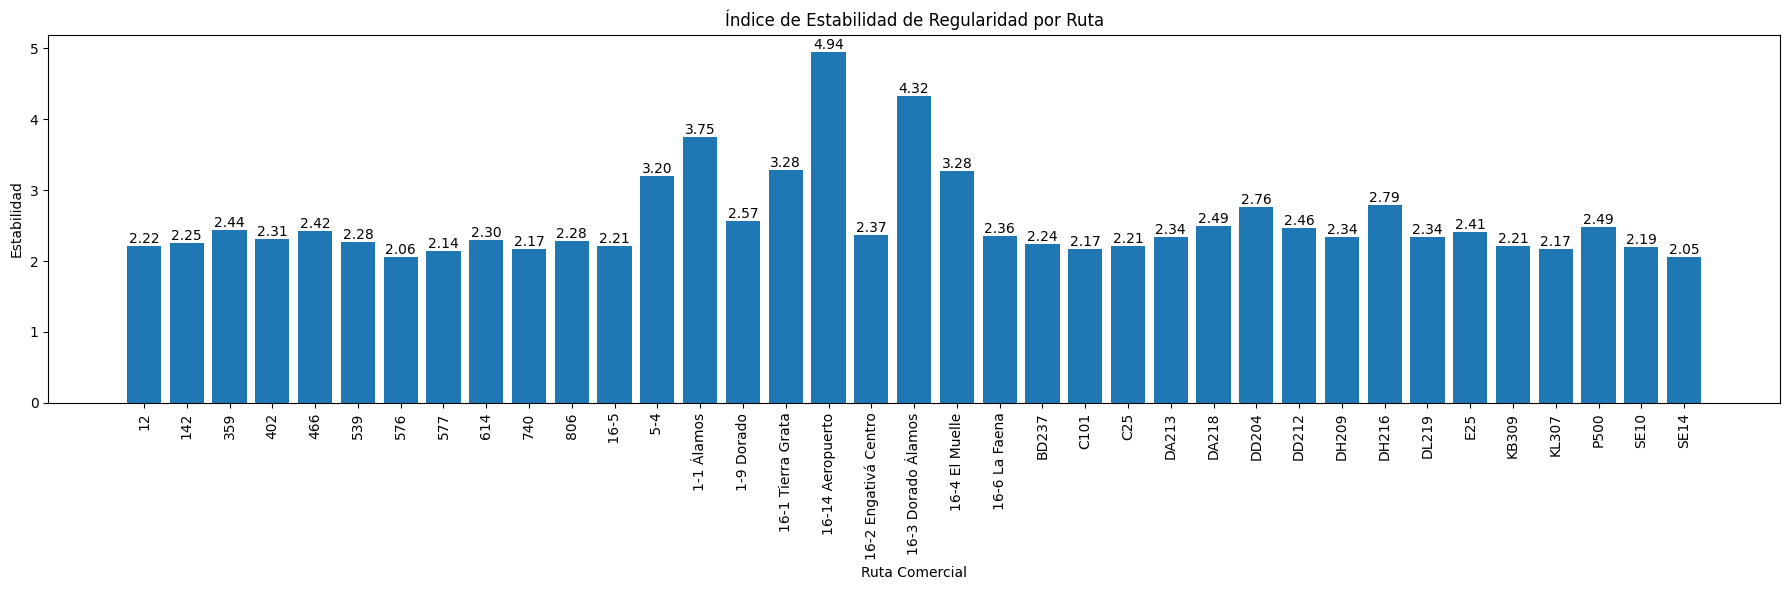

In [12]:
import numpy as np

plt.figure(figsize=(18,6))

x = np.arange(len(estabilidad))

bars = plt.bar(
    x,
    estabilidad["indice_estabilidad"]
)

plt.xticks(
    x,
    estabilidad["Ruta_comercial"],
    rotation=90
)

# Etiquetas de datos
for i, v in enumerate(estabilidad["indice_estabilidad"]):
    plt.text(
        x[i],
        v,
        f"{v:.2f}",
        ha="center",
        va="bottom"
    )

plt.title("Índice de Estabilidad de Regularidad por Ruta")
plt.ylabel("Estabilidad")
plt.xlabel("Ruta Comercial")

plt.tight_layout()
plt.show()

In [13]:
df_iri["primer_viaje_flag"] = df_iri["Primer Viaje"].fillna(0)

df_iri.head()

,IdIRI,Estado,Fecha Viaje,F. Inicio DP,F. Cierre DP,Fuente,Servicio,IdViaje,ViajeLinea,Coche,...,Nodo,Cantidad,Evidencia,Ruta_comercial,Mes,franja,hora_real,hora_programada,retraso_min,primer_viaje_flag
0,85262879,Validado,2026-02-01,2026-02-04,2026-02-10 23:59:59,URBANO,CE06B0015,2,1,15,...,52845.0,1.0,NaN,740,febrero,07,1900-01-01 07:38:55,1900-01-01 07:40:00,-1.083333,0
1,85263393,Validado,2026-02-01,2026-02-04,2026-02-10 23:59:59,URBANO,CE08F0008,8,7,7,...,74036.0,1.0,NaN,806,febrero,17,1900-01-01 17:50:32,1900-01-01 17:50:30,0.033333,0
2,85264191,Validado,2026-02-01,2026-02-04,2026-02-10 23:59:59,URBANO,CE0B10003,13,12,3,...,58634.0,1.0,NaN,5-4,febrero,13,1900-01-01 13:08:30,1900-01-01 13:02:00,6.500000,0
3,85263986,Validado,2026-02-01,2026-02-04,2026-02-10 23:59:59,ALIMENTACION,CE0A60012,18,17,2,...,73713.0,1.0,NaN,16-14 Aeropuerto,febrero,11,1900-01-01 11:36:07,1900-01-01 11:36:00,0.116667,0
4,85264502,Validado,2026-02-01,2026-02-04,2026-02-10 23:59:59,URBANO,CE0D50006,12,6,6,...,58149.0,1.0,NaN,12,febrero,20,1900-01-01 20:00:30,1900-01-01 19:57:30,3.000000,0


In [14]:
retraso_primer = (
    df_iri
    .groupby(["Ruta_comercial", "primer_viaje_flag"])["retraso_min"]
    .mean()
    .reset_index()
)

retraso_primer.head()

,Ruta_comercial,primer_viaje_flag,retraso_min
0,12,0,4.679136
1,12,1,2.265833
2,142,0,3.667691
3,142,1,2.232749
4,359,0,3.328147


In [15]:
retraso_primer = retraso_primer.pivot(
    index="Ruta_comercial",
    columns="primer_viaje_flag",
    values="retraso_min"
).reset_index()

retraso_primer.columns = ["Ruta_comercial", "No_Primer_Viaje", "Primer_Viaje"]

In [16]:
iri_ruta = (
    df_iri
    .groupby("Ruta_comercial")["Viaje Regular"]
    .mean()
    .reset_index()
)
iri_ruta.head()

,Ruta_comercial,Viaje Regular
0,12,0.715929
1,142,0.730971
2,359,0.785304
3,402,0.751469
4,466,0.781888


In [17]:
comparacion = retraso_primer.merge(
    iri_ruta,
    on="Ruta_comercial",
    how="left"
)

comparacion.head()

,Ruta_comercial,No_Primer_Viaje,Primer_Viaje,Viaje Regular
0,12,4.679136,2.265833,0.715929
1,142,3.667691,2.232749,0.730971
2,359,3.328147,1.115873,0.785304
3,402,2.580869,0.724702,0.751469
4,466,3.265870,2.000939,0.781888


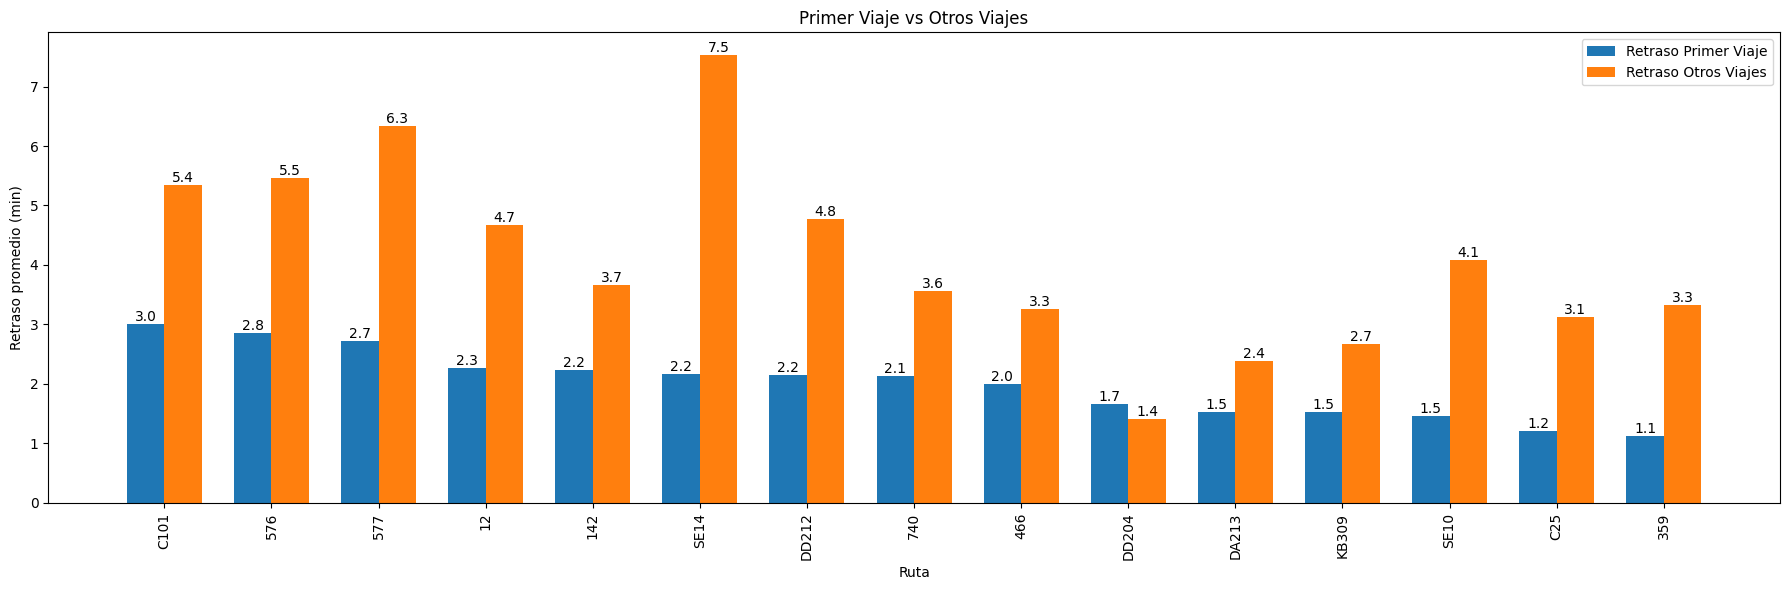

In [18]:
comparacion = comparacion.sort_values("Primer_Viaje", ascending=False).head(15)

x = np.arange(len(comparacion))
width = 0.35

plt.figure(figsize=(18,6))

b1 = plt.bar(
    x - width/2,
    comparacion["Primer_Viaje"],
    width,
    label="Retraso Primer Viaje"
)

b2 = plt.bar(
    x + width/2,
    comparacion["No_Primer_Viaje"],
    width,
    label="Retraso Otros Viajes"
)

plt.xticks(x, comparacion["Ruta_comercial"], rotation=90)

plt.title("Primer Viaje vs Otros Viajes")
plt.ylabel("Retraso promedio (min)")
plt.xlabel("Ruta")
plt.legend()

# etiquetas
for bars in [b1, b2]:
    for bar in bars:
        y = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width()/2,
            y,
            f"{y:.1f}",
            ha="center",
            va="bottom"
        )

plt.tight_layout()
plt.show()

In [19]:
df_iri = df_iri.sort_values(
    ["Ruta_comercial", "Ruta SAE", "hora_real"]
)

df_iri.head()

,IdIRI,Estado,Fecha Viaje,F. Inicio DP,F. Cierre DP,Fuente,Servicio,IdViaje,ViajeLinea,Coche,...,Nodo,Cantidad,Evidencia,Ruta_comercial,Mes,franja,hora_real,hora_programada,retraso_min,primer_viaje_flag
26128,85547654,Validado,2026-02-09,2026-02-11,2026-02-17 23:59:59,URBANO,CE12B0001,2,1,1,...,58149.0,1.0,NaN,12,febrero,03,1900-01-01 03:59:08,1900-01-01 04:00:00,-0.866667,1
12538,85371904,Validado,2026-02-04,2026-02-06,2026-02-12 23:59:59,URBANO,CE12B0001,2,1,1,...,58149.0,1.0,NaN,12,febrero,03,1900-01-01 03:59:46,1900-01-01 04:00:00,-0.233333,1
93307,86310075,Validado,2026-03-02,2026-03-04,2026-03-10 23:59:59,URBANO,CE12B0001,2,1,1,...,58149.0,1.0,NaN,12,marzo,03,1900-01-01 03:59:58,1900-01-01 04:00:00,-0.033333,1
118152,86603122,No Contestado,2026-03-09,2026-03-11,2026-03-17 23:59:59,URBANO,CE12B0001,2,1,1,...,58149.0,1.0,NaN,12,marzo,04,1900-01-01 04:00:02,1900-01-01 04:00:00,0.033333,1
18242,85455022,Validado,2026-02-06,2026-02-10,2026-02-16 23:59:59,URBANO,CE12B0001,2,1,1,...,58149.0,1.0,NaN,12,febrero,04,1900-01-01 04:00:03,1900-01-01 04:00:00,0.050000,1


In [20]:
df_iri["viaje_dia"] = (
    df_iri
    .groupby(["Fecha Viaje", "Ruta_comercial"])
    .cumcount() + 1
)

df_iri.head()

,IdIRI,Estado,Fecha Viaje,F. Inicio DP,F. Cierre DP,Fuente,Servicio,IdViaje,ViajeLinea,Coche,...,Cantidad,Evidencia,Ruta_comercial,Mes,franja,hora_real,hora_programada,retraso_min,primer_viaje_flag,viaje_dia
26128,85547654,Validado,2026-02-09,2026-02-11,2026-02-17 23:59:59,URBANO,CE12B0001,2,1,1,...,1.0,NaN,12,febrero,03,1900-01-01 03:59:08,1900-01-01 04:00:00,-0.866667,1,1.0
12538,85371904,Validado,2026-02-04,2026-02-06,2026-02-12 23:59:59,URBANO,CE12B0001,2,1,1,...,1.0,NaN,12,febrero,03,1900-01-01 03:59:46,1900-01-01 04:00:00,-0.233333,1,1.0
93307,86310075,Validado,2026-03-02,2026-03-04,2026-03-10 23:59:59,URBANO,CE12B0001,2,1,1,...,1.0,NaN,12,marzo,03,1900-01-01 03:59:58,1900-01-01 04:00:00,-0.033333,1,1.0
118152,86603122,No Contestado,2026-03-09,2026-03-11,2026-03-17 23:59:59,URBANO,CE12B0001,2,1,1,...,1.0,NaN,12,marzo,04,1900-01-01 04:00:02,1900-01-01 04:00:00,0.033333,1,1.0
18242,85455022,Validado,2026-02-06,2026-02-10,2026-02-16 23:59:59,URBANO,CE12B0001,2,1,1,...,1.0,NaN,12,febrero,04,1900-01-01 04:00:03,1900-01-01 04:00:00,0.050000,1,1.0


In [21]:
comportamiento = (
    df_iri
    .groupby(["Ruta_comercial", "viaje_dia"])["retraso_min"]
    .mean()
    .reset_index()
)

comportamiento

,Ruta_comercial,viaje_dia,retraso_min
0,12,1.0,1.301307
1,12,2.0,1.657190
2,12,3.0,2.704248
3,12,4.0,2.469281
4,12,5.0,2.693137
...,...,...,...
4385,SE14,177.0,0.616667
4386,SE14,178.0,-0.333333
4387,SE14,179.0,0.208333
4388,SE14,180.0,0.625000


In [22]:
comportamiento1 = (
    df_iri
    .groupby(["Fecha Viaje","Ruta_comercial", "viaje_dia"])["retraso_min"]
    .mean()
    .reset_index()
)

comportamiento1

,Fecha Viaje,Ruta_comercial,viaje_dia,retraso_min
0,2026-02-01,12,1.0,1.100000
1,2026-02-01,12,2.0,0.383333
2,2026-02-01,12,3.0,0.616667
3,2026-02-01,12,4.0,-0.633333
4,2026-02-01,12,5.0,0.066667
...,...,...,...,...
172691,2026-03-24,SE14,112.0,4.433333
172692,2026-03-24,SE14,113.0,5.900000
172693,2026-03-24,SE14,114.0,13.566667
172694,2026-03-24,SE14,115.0,NaN


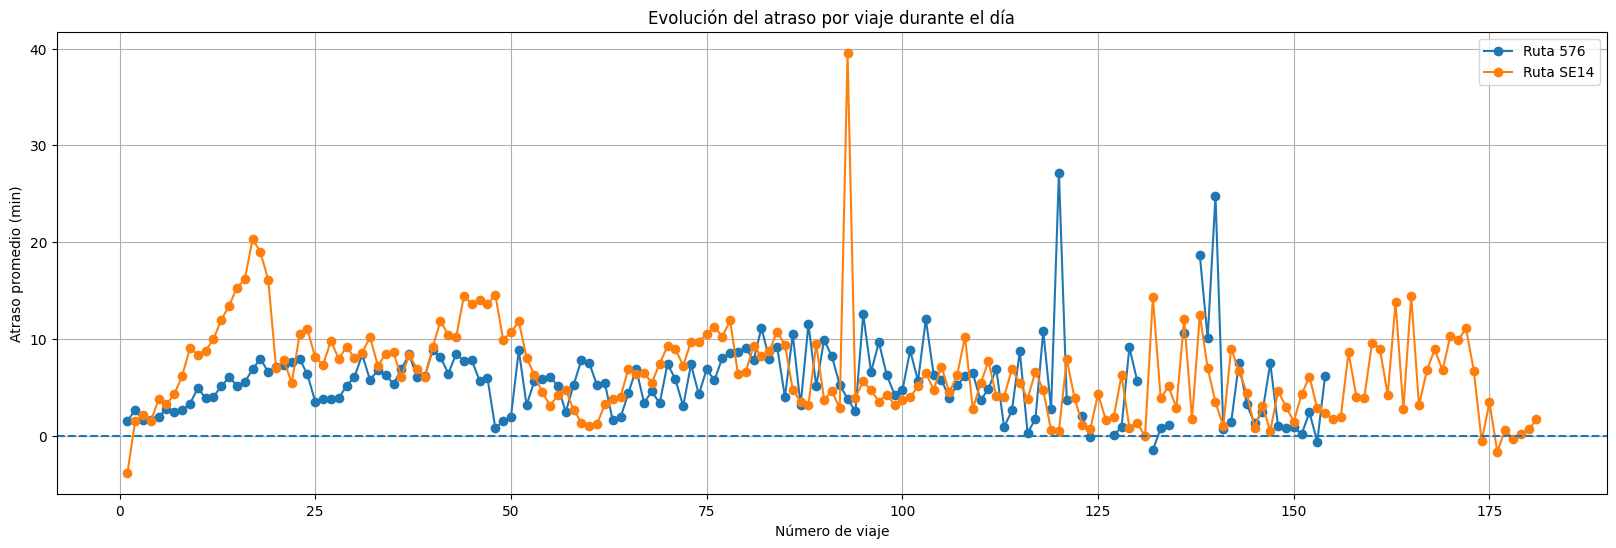

In [23]:
rutas = [576, 'SE14']

plt.figure(figsize=(20,6))

for r in rutas:
    
    df_r = comportamiento[
        comportamiento["Ruta_comercial"] == r
    ]
    
    plt.plot(
        df_r["viaje_dia"],
        df_r["retraso_min"],
        marker="o",
        label=f"Ruta {r}"
    )

plt.axhline(0, linestyle="--")

plt.title("Evolución del atraso por viaje durante el día")
plt.xlabel("Número de viaje")
plt.ylabel("Atraso promedio (min)")

plt.legend()
plt.grid()

plt.show()

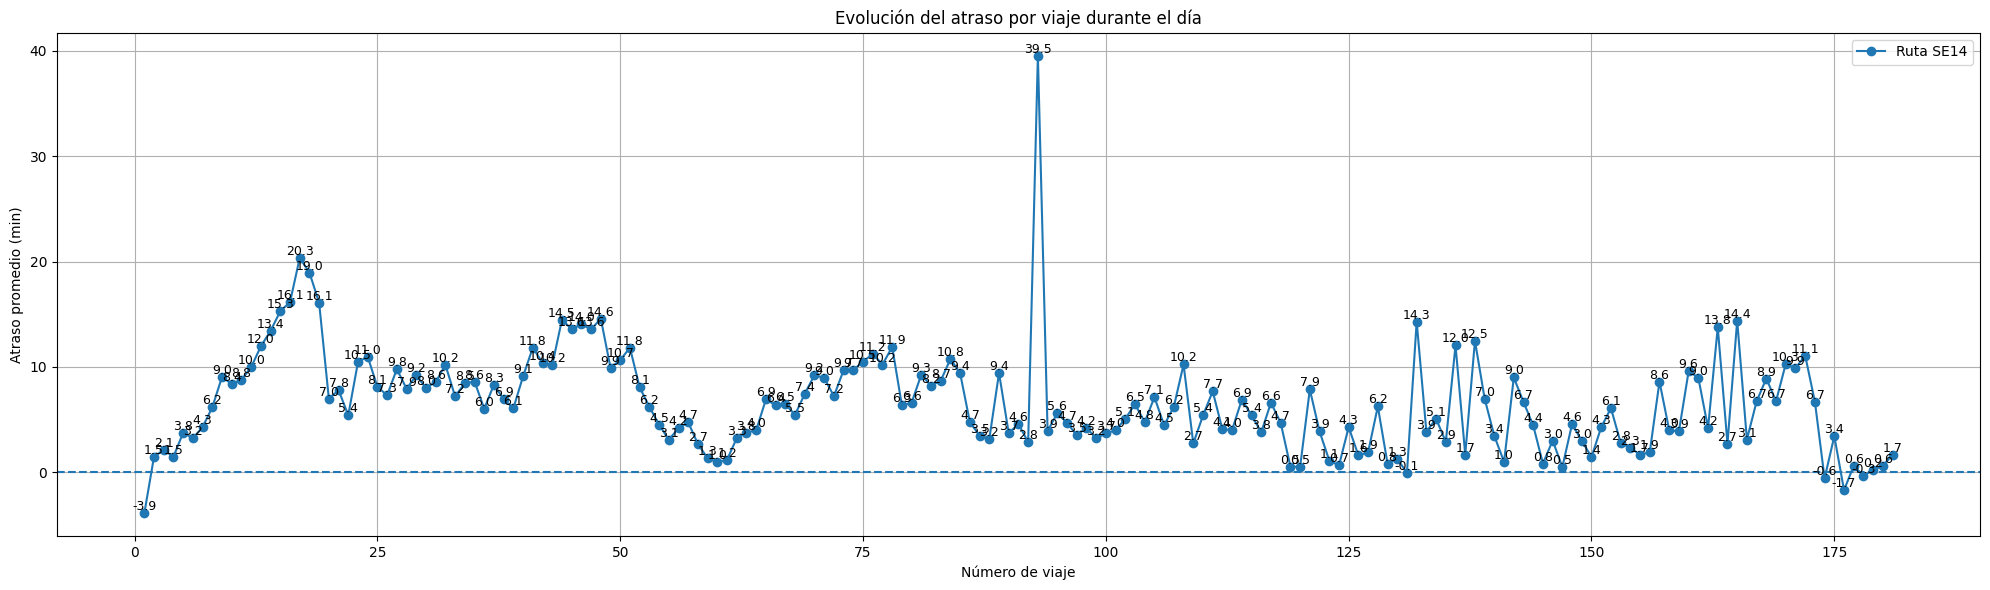

In [24]:
rutas = ['SE14']

plt.figure(figsize=(20,6))

for r in rutas:
    
    df_r = comportamiento[
        comportamiento["Ruta_comercial"] == r
    ]
    
    plt.plot(
        df_r["viaje_dia"],
        df_r["retraso_min"],
        marker="o",
        label=f"Ruta {r}"
    )
    
    # Agregar etiquetas de datos
    for x, y in zip(df_r["viaje_dia"], df_r["retraso_min"]):
        plt.text(
            x, 
            y, 
            f"{y:.1f}", 
            ha='center', 
            va='bottom',
            fontsize=9
        )

plt.axhline(0, linestyle="--")

plt.title("Evolución del atraso por viaje durante el día")
plt.xlabel("Número de viaje")
plt.ylabel("Atraso promedio (min)")

plt.legend()
plt.grid()

plt.tight_layout()

plt.show()

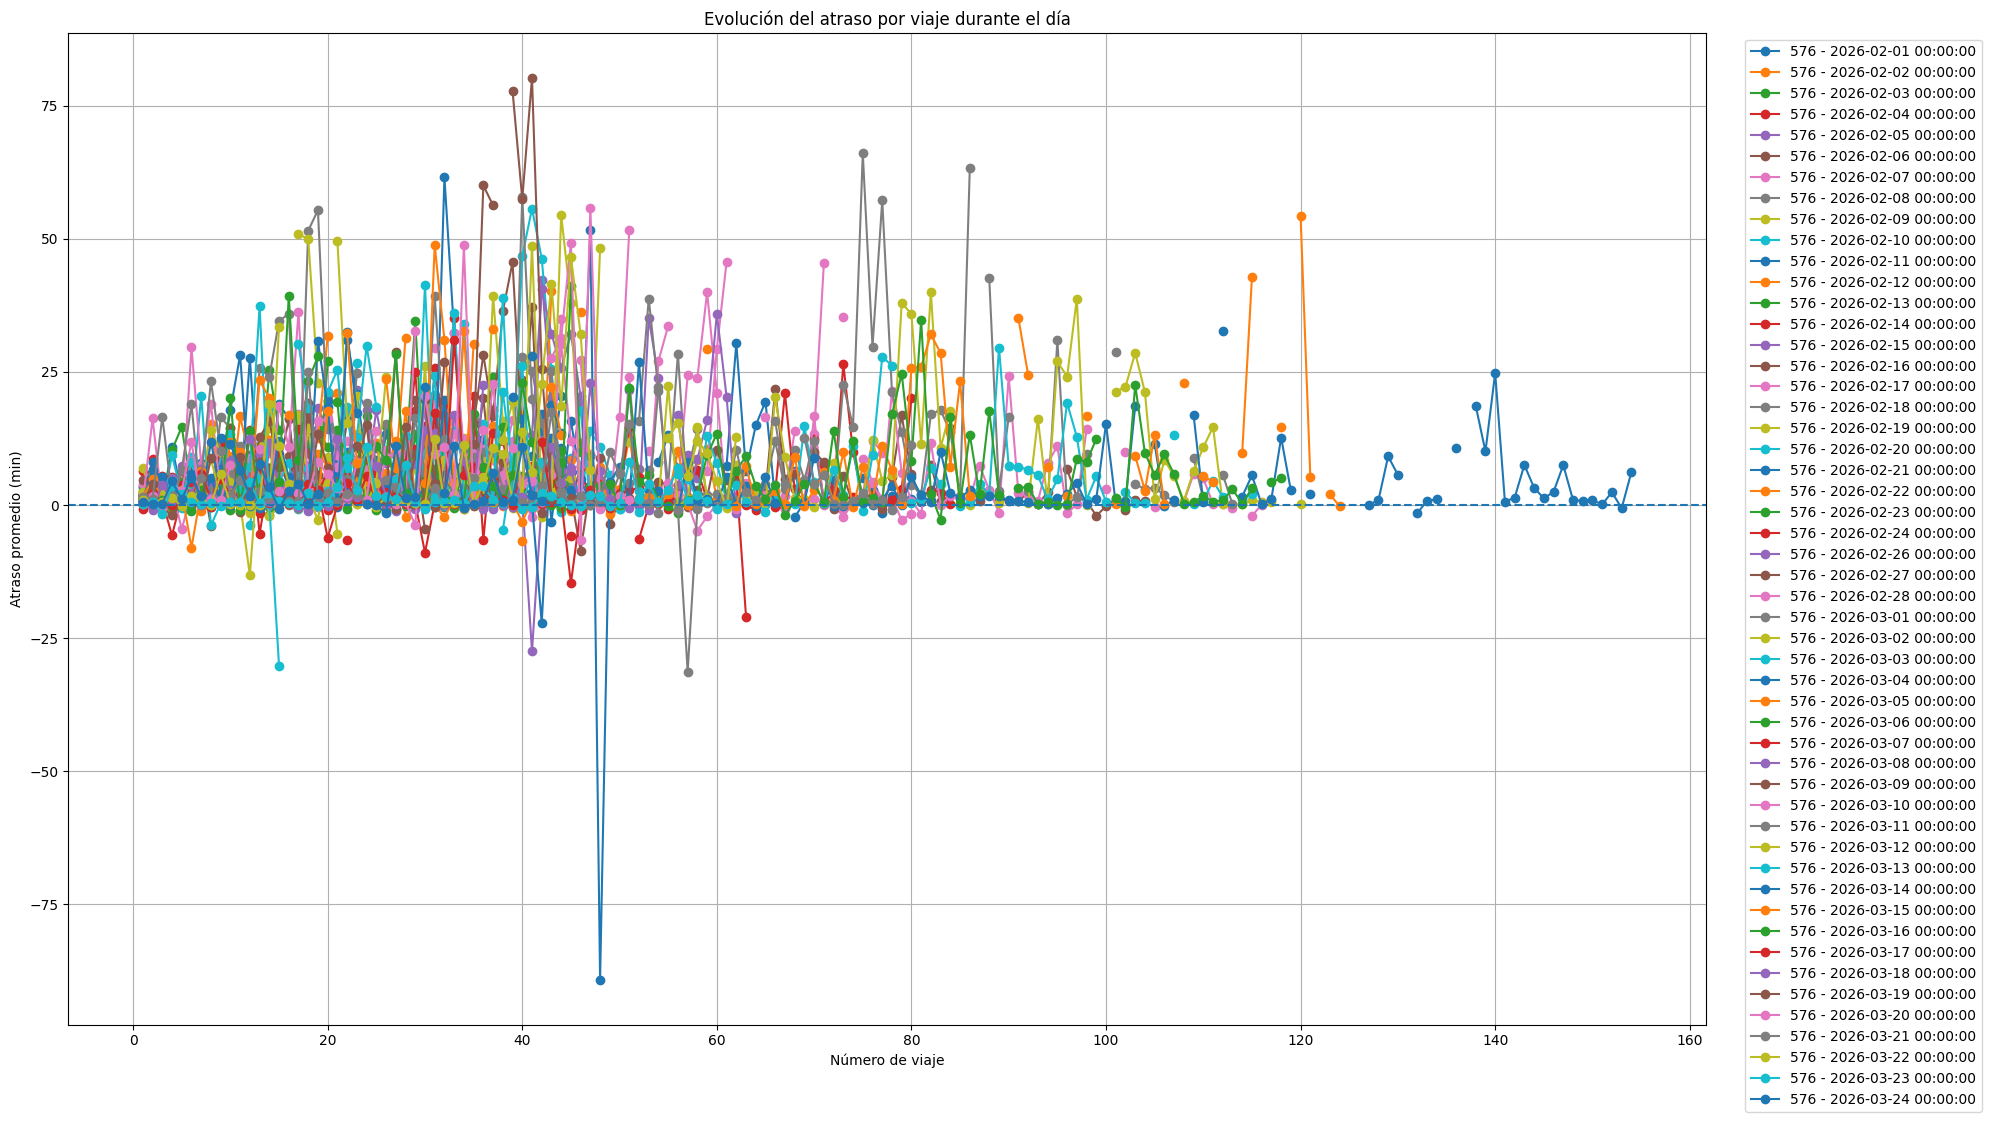

In [25]:
rutas = [576]

plt.figure(figsize=(20,12))

for r in rutas:
    
    df_r = comportamiento1[
        comportamiento1["Ruta_comercial"] == r
    ]
    
    for fecha in df_r["Fecha Viaje"].unique():
        
        df_rf = df_r[df_r["Fecha Viaje"] == fecha]
        
        plt.plot(
            df_rf["viaje_dia"],
            df_rf["retraso_min"],
            marker="o",
            label=f"{r} - {fecha}"
        )

plt.axhline(0, linestyle="--")

plt.title("Evolución del atraso por viaje durante el día")
plt.xlabel("Número de viaje")
plt.ylabel("Atraso promedio (min)")

plt.legend(bbox_to_anchor=(1.02,1))
plt.grid()

plt.tight_layout()

plt.show()

In [26]:
df_iri.head()

,IdIRI,Estado,Fecha Viaje,F. Inicio DP,F. Cierre DP,Fuente,Servicio,IdViaje,ViajeLinea,Coche,...,Cantidad,Evidencia,Ruta_comercial,Mes,franja,hora_real,hora_programada,retraso_min,primer_viaje_flag,viaje_dia
26128,85547654,Validado,2026-02-09,2026-02-11,2026-02-17 23:59:59,URBANO,CE12B0001,2,1,1,...,1.0,NaN,12,febrero,03,1900-01-01 03:59:08,1900-01-01 04:00:00,-0.866667,1,1.0
12538,85371904,Validado,2026-02-04,2026-02-06,2026-02-12 23:59:59,URBANO,CE12B0001,2,1,1,...,1.0,NaN,12,febrero,03,1900-01-01 03:59:46,1900-01-01 04:00:00,-0.233333,1,1.0
93307,86310075,Validado,2026-03-02,2026-03-04,2026-03-10 23:59:59,URBANO,CE12B0001,2,1,1,...,1.0,NaN,12,marzo,03,1900-01-01 03:59:58,1900-01-01 04:00:00,-0.033333,1,1.0
118152,86603122,No Contestado,2026-03-09,2026-03-11,2026-03-17 23:59:59,URBANO,CE12B0001,2,1,1,...,1.0,NaN,12,marzo,04,1900-01-01 04:00:02,1900-01-01 04:00:00,0.033333,1,1.0
18242,85455022,Validado,2026-02-06,2026-02-10,2026-02-16 23:59:59,URBANO,CE12B0001,2,1,1,...,1.0,NaN,12,febrero,04,1900-01-01 04:00:03,1900-01-01 04:00:00,0.050000,1,1.0


In [27]:
df_iri['franja'] = df_iri['franja'].astype(int)

In [28]:
def asignar_franja(h):
    
    if 4 <= h < 6:
        return "Inicio operación"
    
    elif 6 <= h < 9:
        return "Pico AM"
    
    elif 9 <= h < 16:
        return "Valle"
    
    elif 16 <= h < 19:
        return "Pico PM"
    
    elif 19 <= h < 22:
        return "Noche"
    
    else:
        return "Cierre"

df_iri['Franja_op'] = df_iri['franja'].apply(asignar_franja)

In [29]:
resumen = df_iri.groupby(
    ['Ruta_comercial','Ruta SAE','Franja_op']
)['retraso_min'].mean().reset_index()

resumen

,Ruta_comercial,Ruta SAE,Franja_op,retraso_min
0,12,10632,Cierre,1.231818
1,12,10632,Inicio operación,2.586371
2,12,10632,Noche,9.487104
3,12,10632,Pico AM,5.346066
4,12,10632,Pico PM,3.160114
...,...,...,...,...
473,SE14,12739,Inicio operación,1.001418
474,SE14,12739,Noche,6.873746
475,SE14,12739,Pico AM,3.769316
476,SE14,12739,Pico PM,6.220450


In [30]:
resumen1 = df_iri.groupby(
    ['Ruta_comercial','Ruta SAE','franja']
)['retraso_min'].mean().reset_index()

resumen1

,Ruta_comercial,Ruta SAE,franja,retraso_min
0,12,10632,3,-0.377778
1,12,10632,4,1.908941
2,12,10632,5,3.227094
3,12,10632,6,3.611301
4,12,10632,7,7.080316
...,...,...,...,...
1588,SE14,12739,19,10.079078
1589,SE14,12739,20,4.881090
1590,SE14,12739,21,3.514286
1591,SE14,12739,22,-0.066667


In [31]:
resumen2 = df_iri.groupby(
    ['Fecha Viaje','Ruta_comercial','Ruta SAE','Franja_op']
)['retraso_min'].mean().reset_index()

resumen2

,Fecha Viaje,Ruta_comercial,Ruta SAE,Franja_op,retraso_min
0,2026-02-01,12,12475,Inicio operación,0.700000
1,2026-02-01,12,12475,Noche,9.433333
2,2026-02-01,12,12475,Pico AM,0.254167
3,2026-02-01,12,12475,Pico PM,4.312500
4,2026-02-01,12,12475,Valle,2.666667
...,...,...,...,...,...
13455,2026-03-24,SE14,12739,Inicio operación,0.476667
13456,2026-03-24,SE14,12739,Noche,13.566667
13457,2026-03-24,SE14,12739,Pico AM,15.369444
13458,2026-03-24,SE14,12739,Pico PM,5.887037


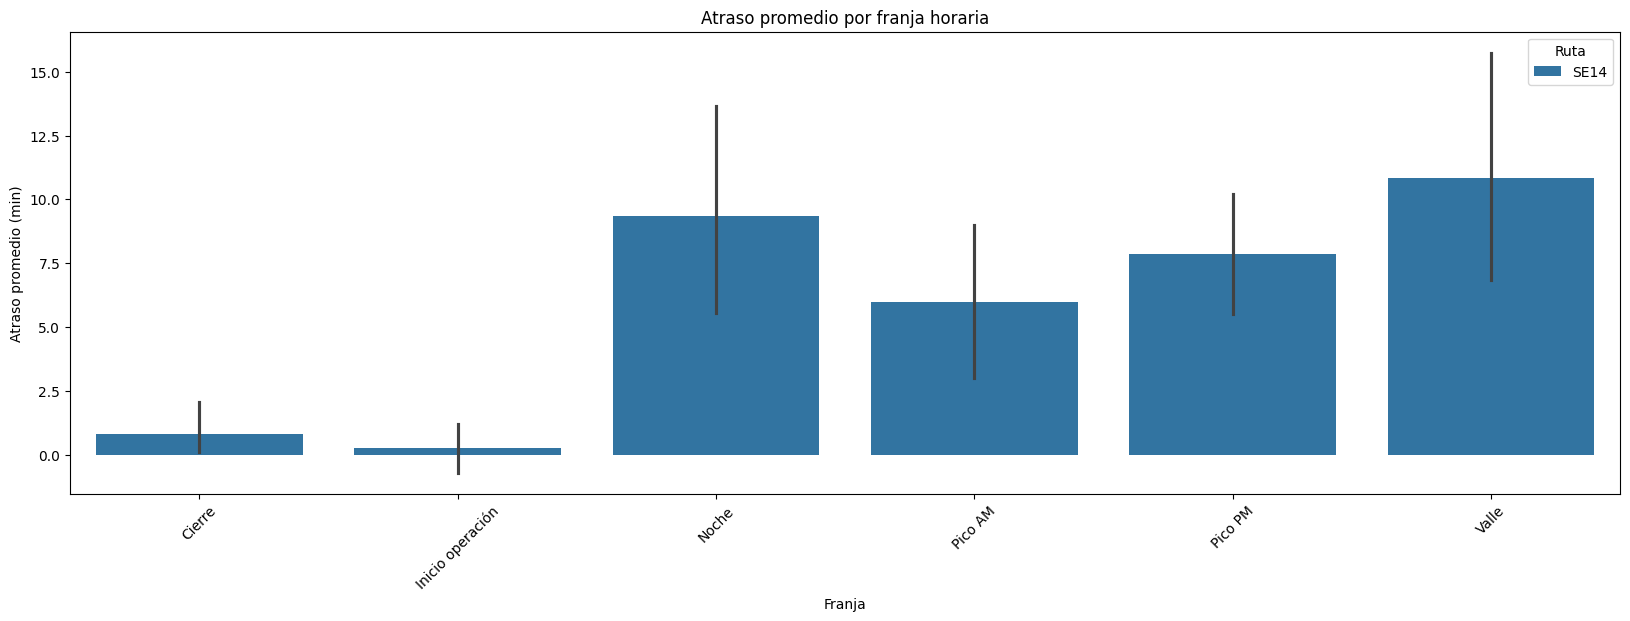

In [32]:
rutas = ['SE14']

resumen_filtrado = resumen[
    resumen['Ruta_comercial'].isin(rutas)
]

plt.figure(figsize=(20,6))

sns.barplot(
    data=resumen_filtrado,
    x='Franja_op',
    y='retraso_min',
    hue='Ruta_comercial'
)

plt.title("Atraso promedio por franja horaria")
plt.xlabel("Franja")
plt.ylabel("Atraso promedio (min)")

plt.xticks(rotation=45)

plt.legend(title="Ruta")

plt.show()

<Axes: xlabel='Franja_op', ylabel='retraso_min'>

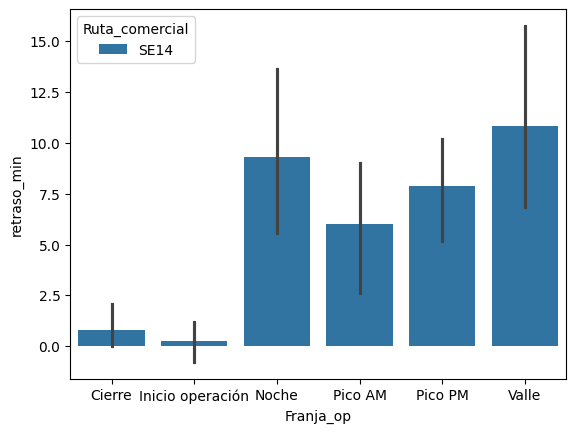

In [33]:
orden_franja = sorted(resumen_filtrado['Franja_op'].unique())

sns.barplot(
    data=resumen_filtrado,
    x='Franja_op',
    y='retraso_min',
    hue='Ruta_comercial',
    order=orden_franja
)

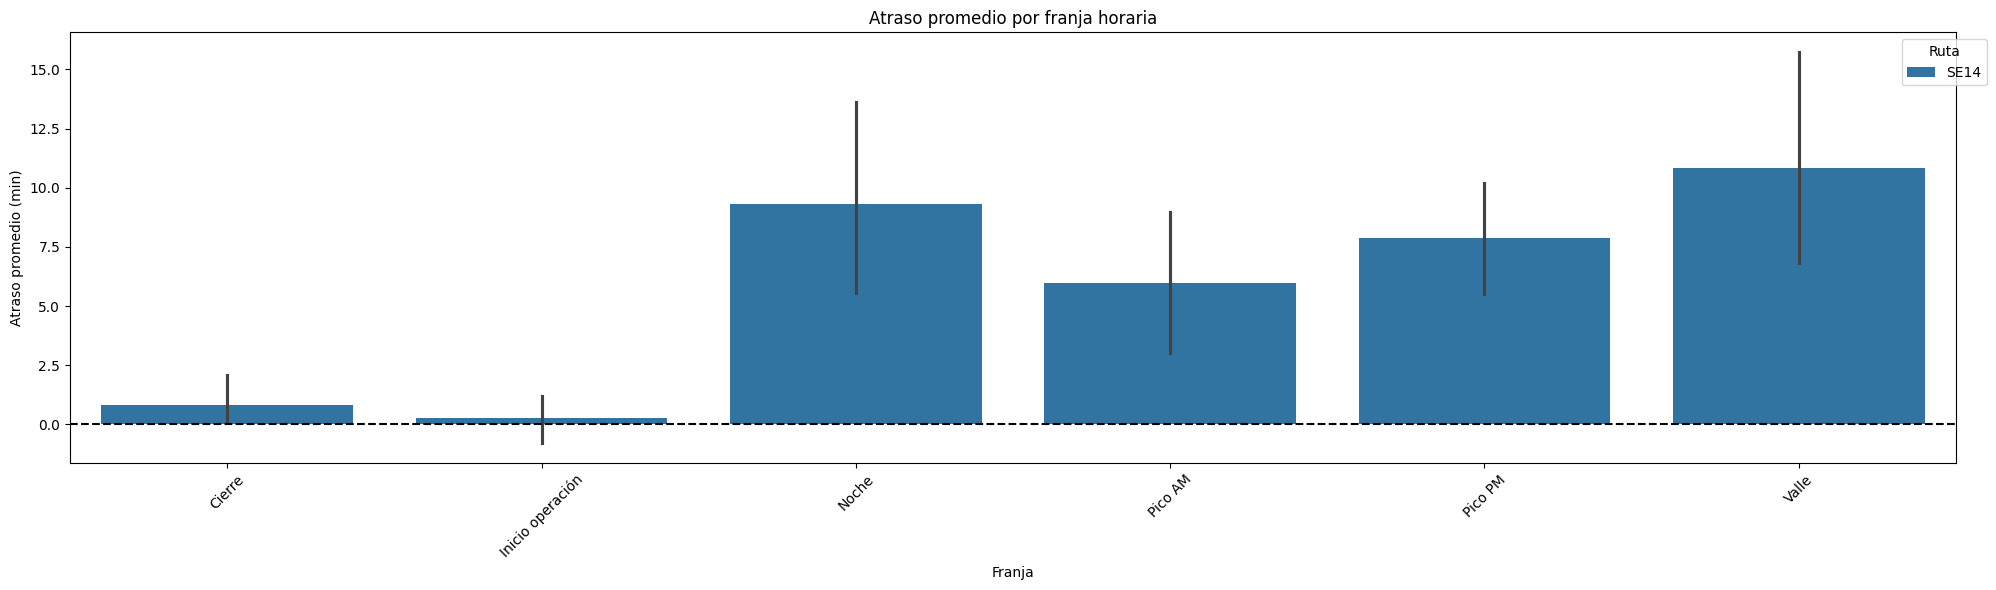

In [34]:
plt.figure(figsize=(20,6))

sns.barplot(
    data=resumen_filtrado,
    x='Franja_op',
    y='retraso_min',
    hue='Ruta_comercial'
)

plt.axhline(0, linestyle="--", color="black")

plt.title("Atraso promedio por franja horaria")
plt.xlabel("Franja")
plt.ylabel("Atraso promedio (min)")

plt.xticks(rotation=45)

plt.legend(title="Ruta", bbox_to_anchor=(1.02,1))

plt.tight_layout()

plt.show()

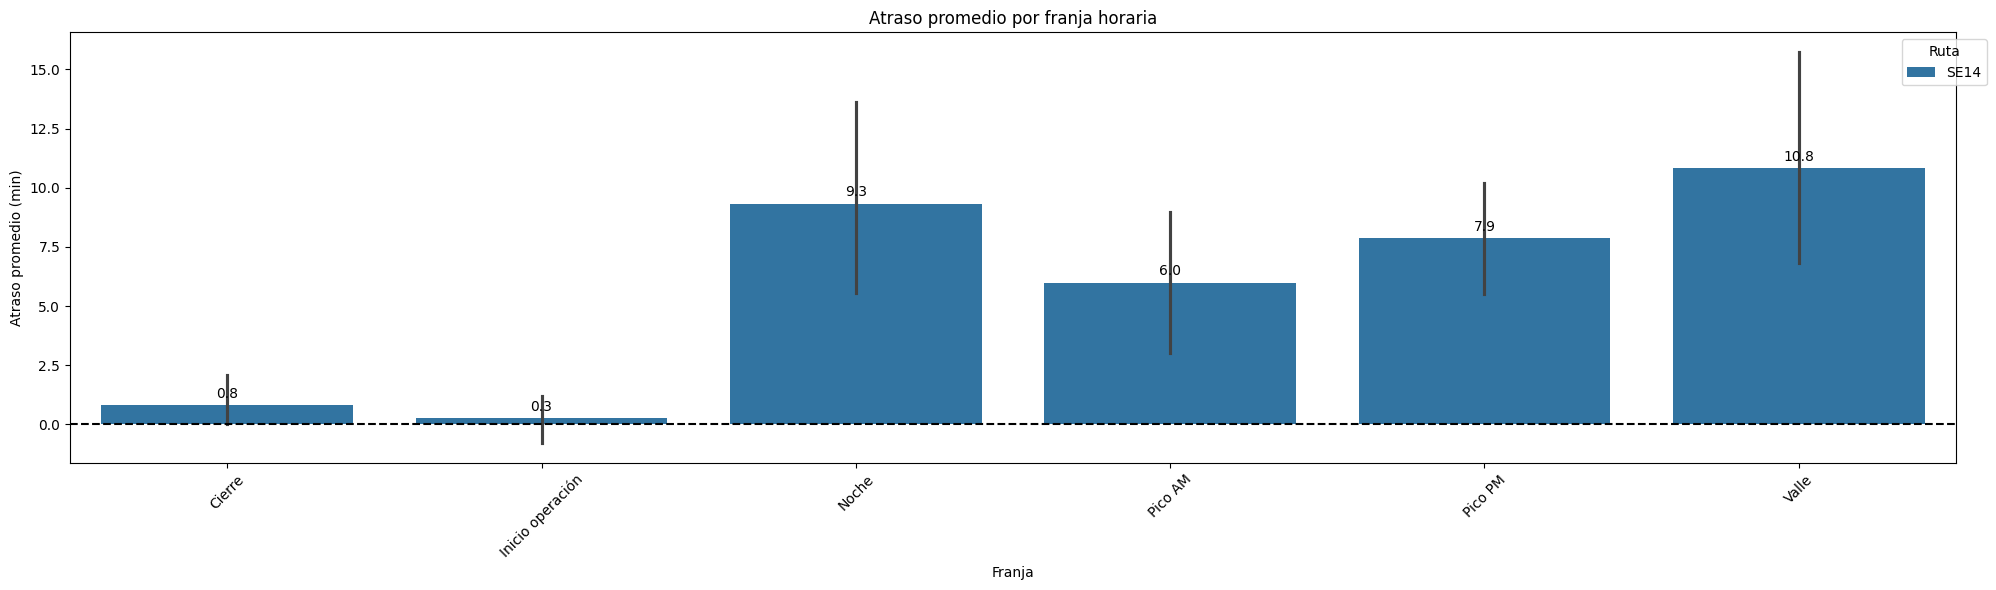

In [35]:
plt.figure(figsize=(20,6))

ax = sns.barplot(
    data=resumen_filtrado,
    x='Franja_op',
    y='retraso_min',
    hue='Ruta_comercial'
)

plt.axhline(0, linestyle="--", color="black")

plt.title("Atraso promedio por franja horaria")
plt.xlabel("Franja")
plt.ylabel("Atraso promedio (min)")

plt.xticks(rotation=45)

plt.legend(title="Ruta", bbox_to_anchor=(1.02,1))

# Mostrar etiquetas
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f', padding=3)

plt.tight_layout()

plt.show()

In [36]:
g1 = df_iri.groupby(['Fecha Viaje','Ruta_comercial']).agg(
    viajes_regulares=('Viaje Regular', lambda x: (x == 1).sum()),
    total=('Cantidad','sum')
).reset_index()

g1['IRI_pct'] = g1['viajes_regulares'] / g1['total'] * 100

g1

,Fecha Viaje,Ruta_comercial,viajes_regulares,total,IRI_pct
0,2026-02-01,12,33,42.0,78.571429
1,2026-02-01,142,32,42.0,76.190476
2,2026-02-01,359,34,44.0,77.272727
3,2026-02-01,402,38,49.0,77.551020
4,2026-02-01,466,40,57.0,70.175439
...,...,...,...,...,...
1873,2026-03-24,KB309,42,65.0,64.615385
1874,2026-03-24,KL307,63,94.0,67.021277
1875,2026-03-24,P500,42,54.0,77.777778
1876,2026-03-24,SE10,61,92.0,66.304348


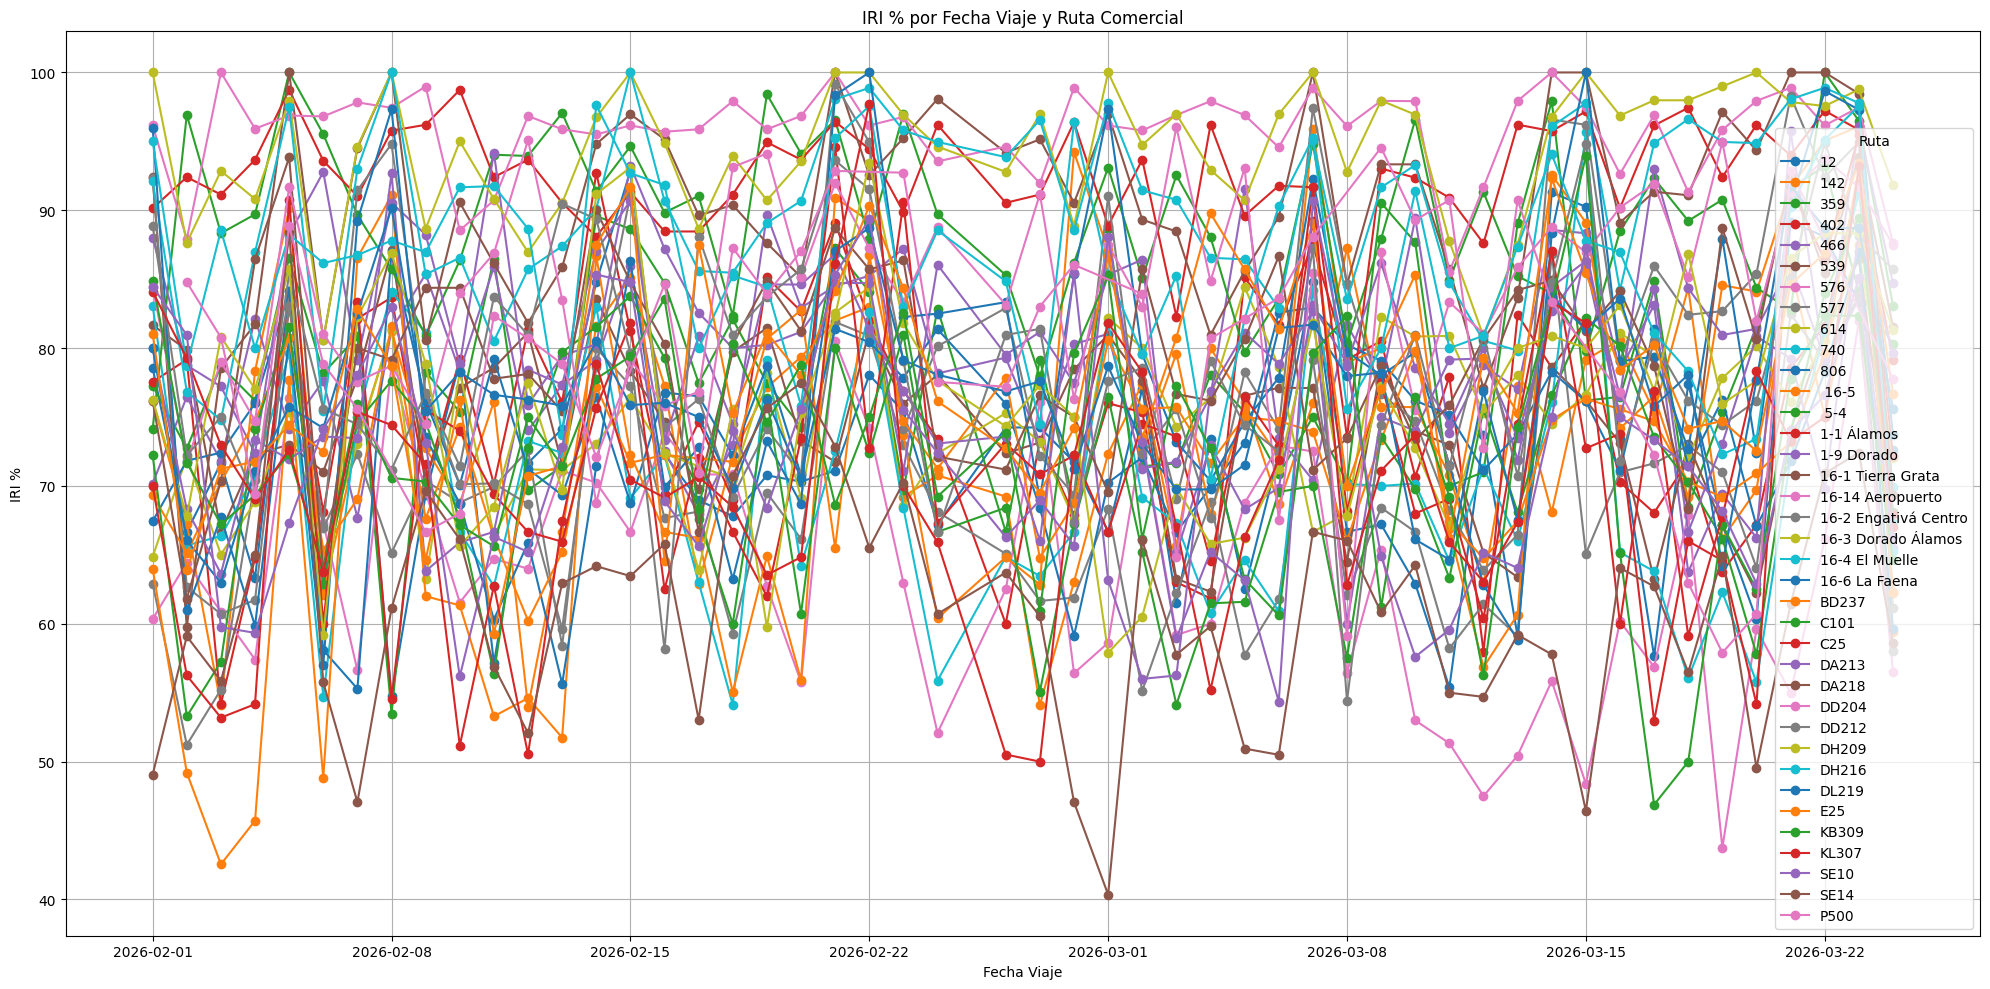

In [37]:
plt.figure(figsize=(20,10))

for ruta in g1['Ruta_comercial'].unique():
    
    data = g1[g1['Ruta_comercial']==ruta]
    
    plt.plot(
        data['Fecha Viaje'],
        data['IRI_pct'],
        marker='o',
        label=ruta
    )

plt.title('IRI % por Fecha Viaje y Ruta Comercial')
plt.xlabel('Fecha Viaje')
plt.ylabel('IRI %')
plt.legend(title='Ruta')
plt.grid(True)

plt.tight_layout()
plt.show()

In [38]:
g2 = df_iri.groupby(['Ruta_comercial','franja']).agg(
    viajes_regulares=('Viaje Regular', lambda x: (x == 1).sum()),
    total=('Cantidad','sum')
).reset_index()

g2['IRI_pct'] = g2['viajes_regulares'] / g2['total'] * 100

g2

,Ruta_comercial,franja,viajes_regulares,total,IRI_pct
0,12,3,3,3.0,100.000000
1,12,4,162,193.0,83.937824
2,12,5,172,230.0,74.782609
3,12,6,140,233.0,60.085837
4,12,7,123,184.0,66.847826
...,...,...,...,...,...
768,SE14,19,103,273.0,37.728938
769,SE14,20,138,252.0,54.761905
770,SE14,21,52,91.0,57.142857
771,SE14,22,70,87.0,80.459770


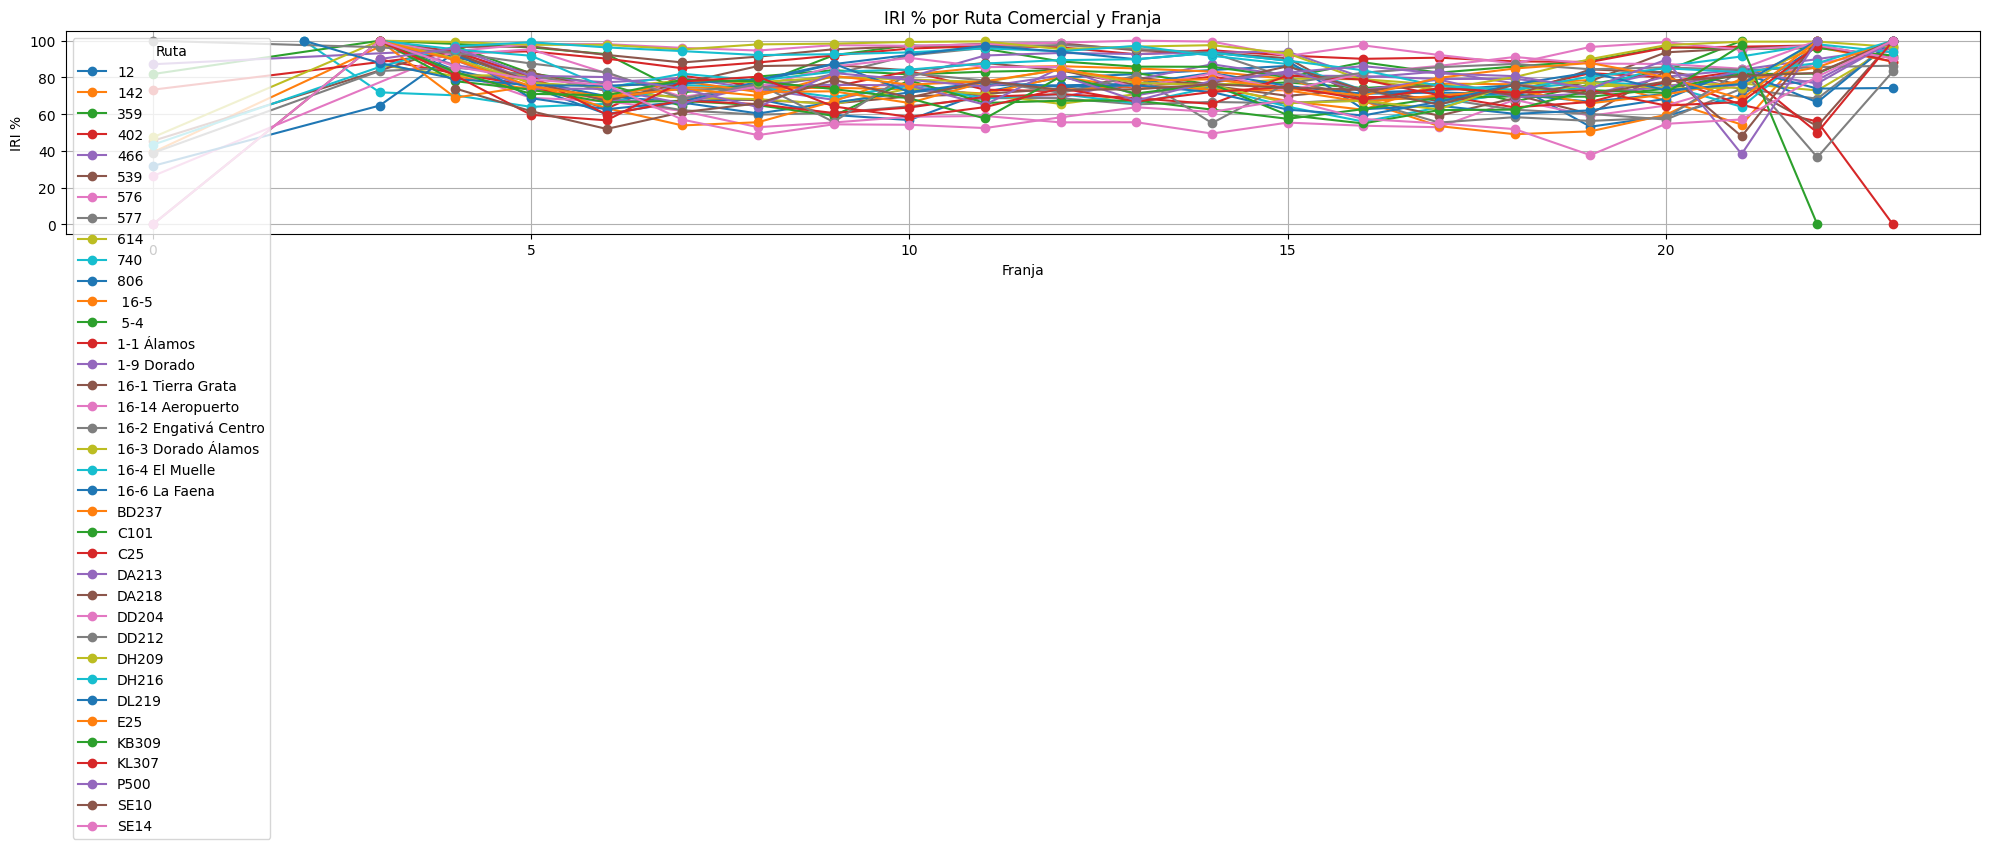

In [39]:
plt.figure(figsize=(20,6))

for ruta in g2['Ruta_comercial'].unique():
    
    data = g2[g2['Ruta_comercial']==ruta]
    
    plt.plot(
        data['franja'],
        data['IRI_pct'],
        marker='o',
        label=ruta
    )

plt.title('IRI % por Ruta Comercial y Franja')
plt.xlabel('Franja')
plt.ylabel('IRI %')
plt.legend(title='Ruta')
plt.grid(True)

plt.tight_layout()
plt.show()

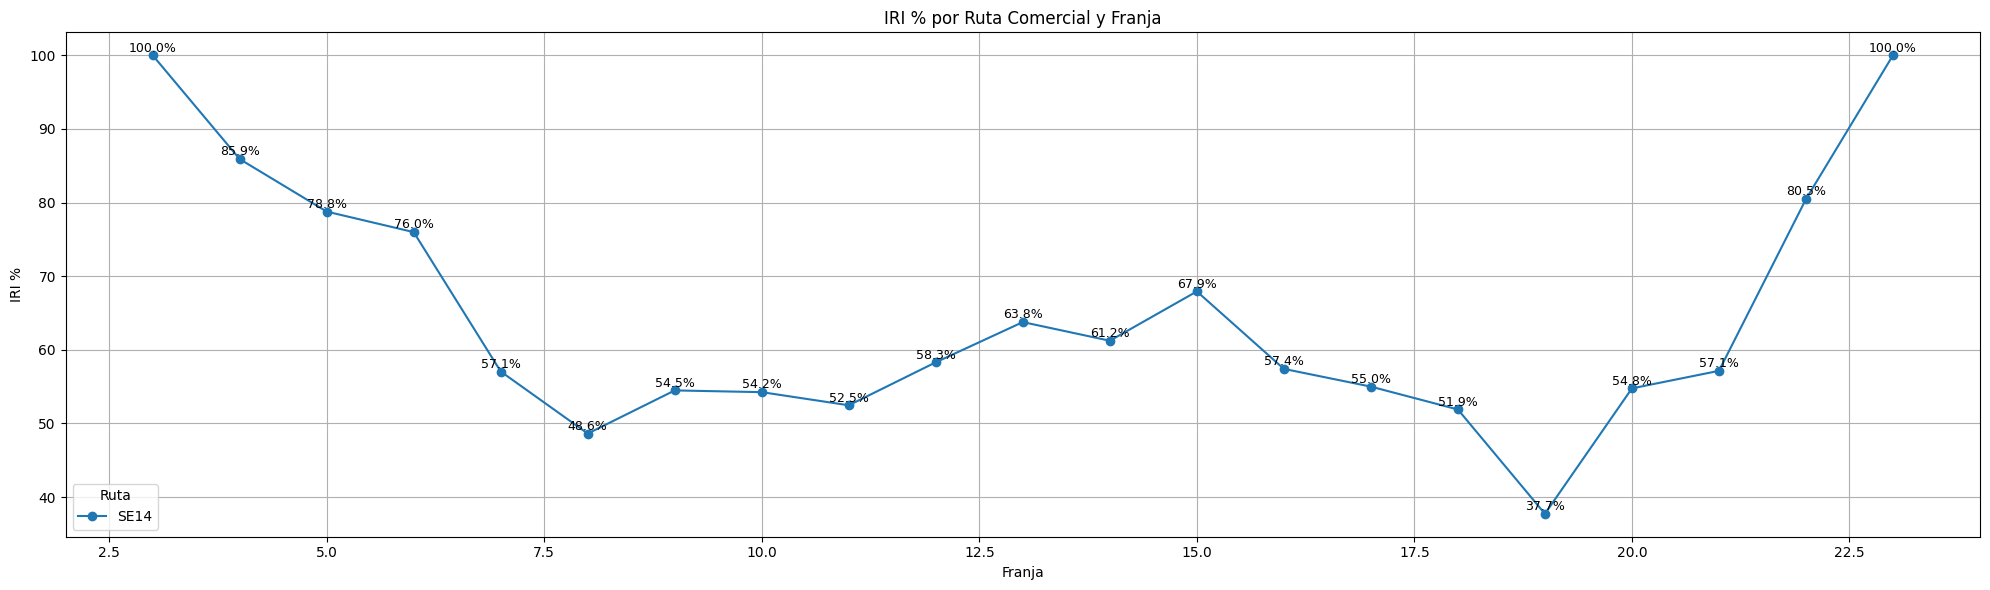

In [40]:
rutas_filtro = ['SE14']

g2_filtrado = g2[g2['Ruta_comercial'].isin(rutas_filtro)]

plt.figure(figsize=(20,6))

for ruta in g2_filtrado['Ruta_comercial'].unique():
    
    data = g2_filtrado[g2_filtrado['Ruta_comercial'] == ruta]
    
    plt.plot(
        data['franja'],
        data['IRI_pct'],
        marker='o',
        label=ruta
    )
    
    # Etiquetas de datos
    for x, y in zip(data['franja'], data['IRI_pct']):
        plt.text(
            x,
            y + 0.5,
            f'{y:.1f}%',
            ha='center',
            fontsize=9
        )

plt.title('IRI % por Ruta Comercial y Franja')
plt.xlabel('Franja')
plt.ylabel('IRI %')
plt.legend(title='Ruta')
plt.grid(True)

plt.tight_layout()
plt.show()

In [41]:
g3 = df_iri.groupby(['Ruta_comercial','Franja_op']).agg(
    viajes_regulares=('Viaje Regular', lambda x: (x == 1).sum()),
    total=('Cantidad','sum')
).reset_index()

g3['IRI_pct'] = g3['viajes_regulares'] / g3['total'] * 100

g3

,Ruta_comercial,Franja_op,viajes_regulares,total,IRI_pct
0,12,Cierre,36,37.0,97.297297
1,12,Inicio operación,334,423.0,78.959811
2,12,Noche,196,329.0,59.574468
3,12,Pico AM,379,587.0,64.565588
4,12,Pico PM,342,466.0,73.390558
...,...,...,...,...,...
216,SE14,Inicio operación,544,663.0,82.051282
217,SE14,Noche,293,616.0,47.564935
218,SE14,Pico AM,647,1047.0,61.795606
219,SE14,Pico PM,466,848.0,54.952830


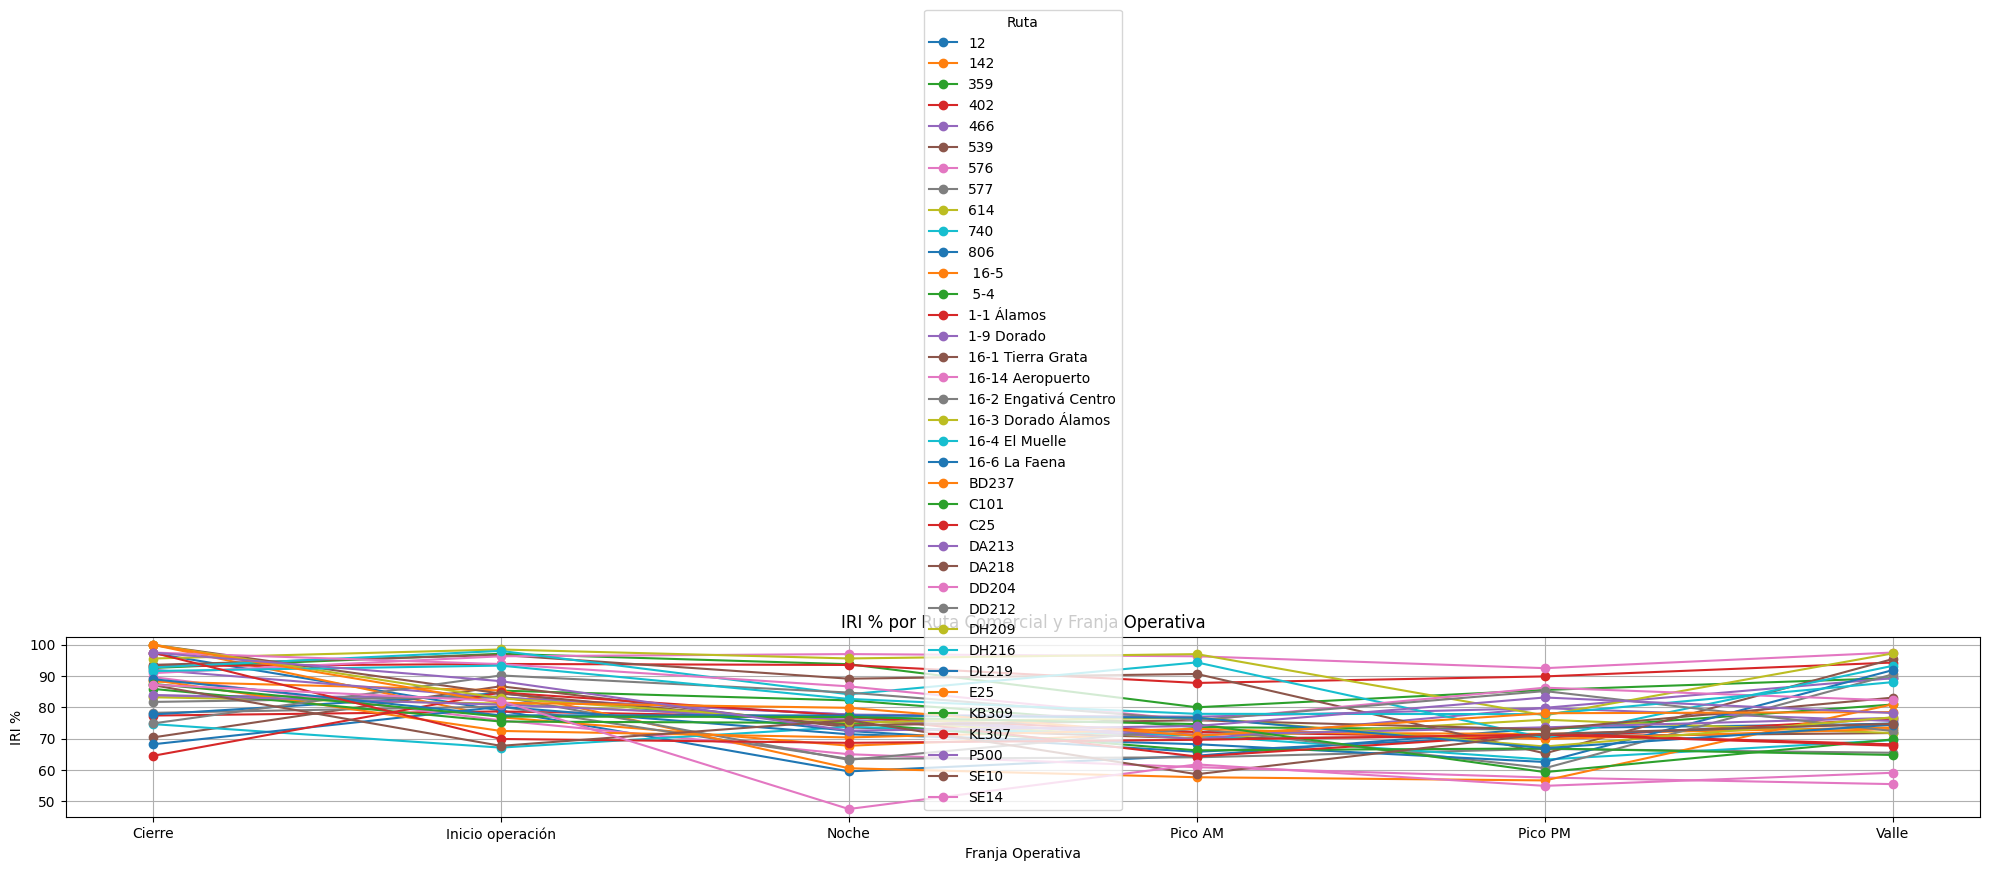

In [42]:
plt.figure(figsize=(20,6))

for ruta in g3['Ruta_comercial'].unique():
    
    data = g3[g3['Ruta_comercial']==ruta]
    
    plt.plot(
        data['Franja_op'],
        data['IRI_pct'],
        marker='o',
        label=ruta
    )

plt.title('IRI % por Ruta Comercial y Franja Operativa')
plt.xlabel('Franja Operativa')
plt.ylabel('IRI %')
plt.legend(title='Ruta')
plt.grid(True)

plt.tight_layout()
plt.show()

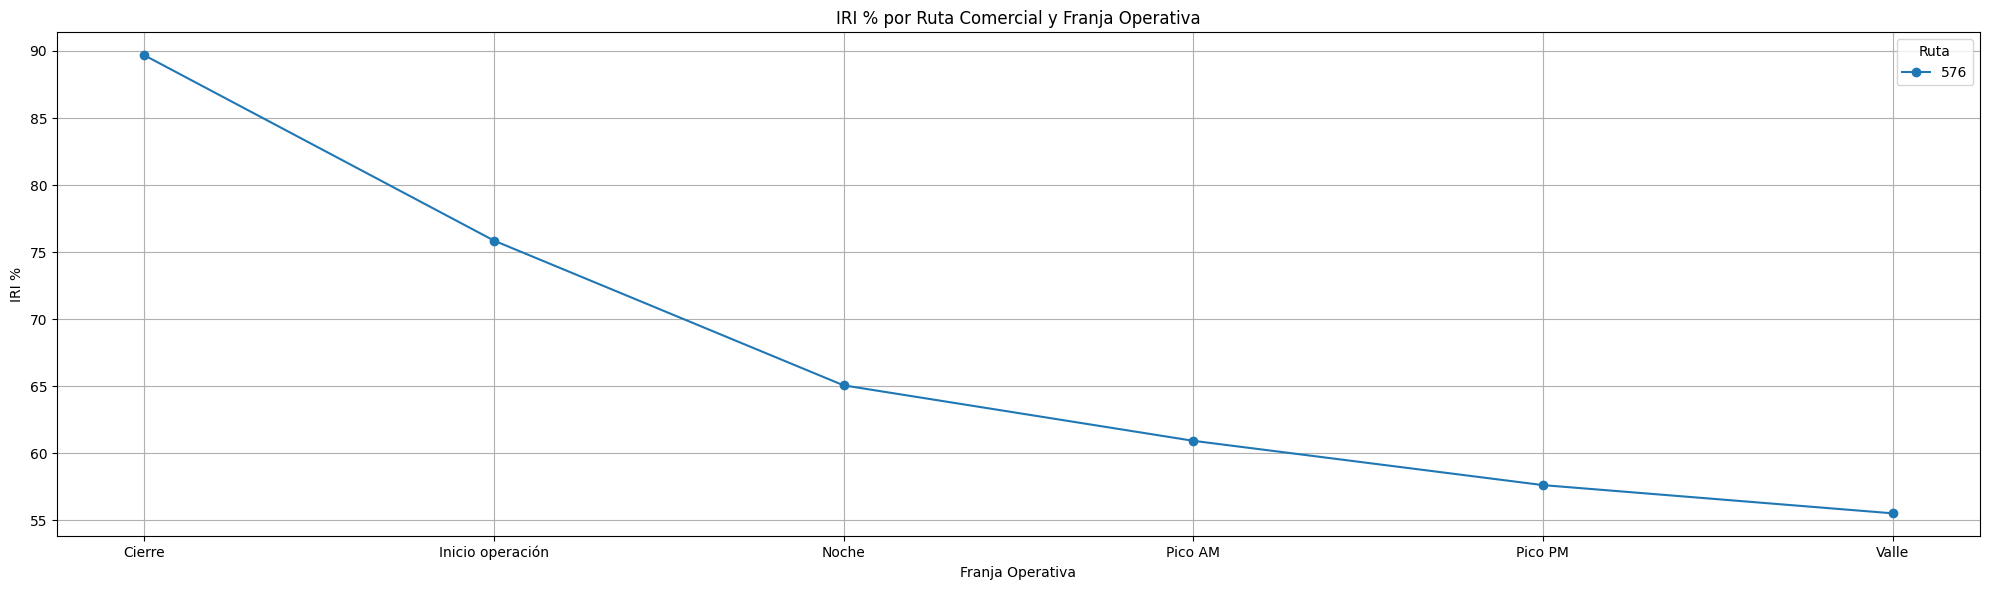

In [43]:
rutas_filtro = [576]

g3_filtrado = g3[g3['Ruta_comercial'].isin(rutas_filtro)]

plt.figure(figsize=(20,6))

for ruta in g3_filtrado['Ruta_comercial'].unique():
    
    data = g3_filtrado[g3_filtrado['Ruta_comercial'] == ruta]
    
    plt.plot(
        data['Franja_op'],
        data['IRI_pct'],
        marker='o',
        label=ruta
    )

plt.title('IRI % por Ruta Comercial y Franja Operativa')
plt.xlabel('Franja Operativa')
plt.ylabel('IRI %')
plt.legend(title='Ruta')
plt.grid(True)

plt.tight_layout()
plt.show()

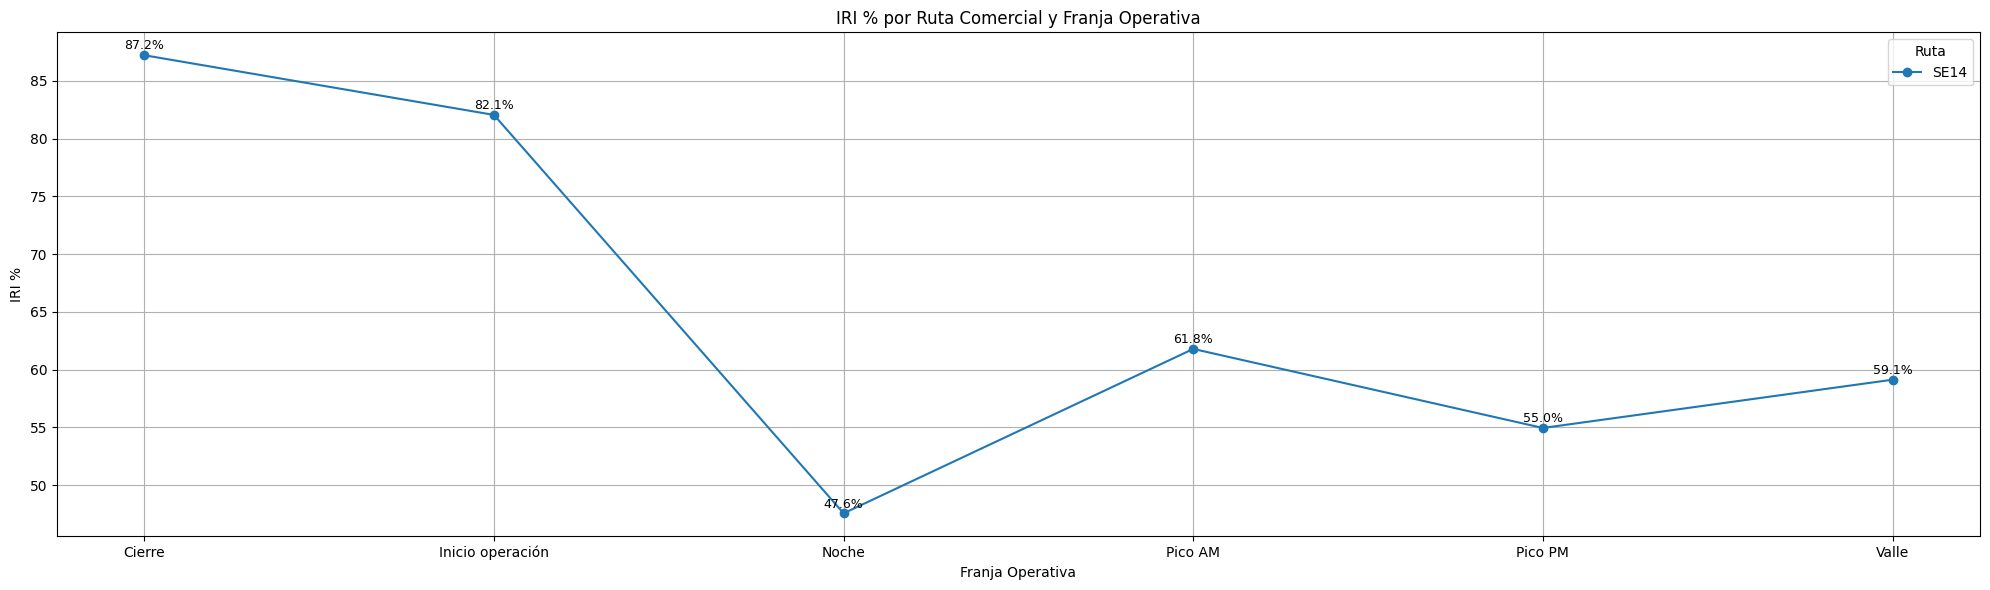

In [44]:
rutas_filtro = ['SE14'] 

g3_filtrado = g3[g3['Ruta_comercial'].isin(rutas_filtro)]

plt.figure(figsize=(20,6))

for ruta in g3_filtrado['Ruta_comercial'].unique():
    
    data = g3_filtrado[g3_filtrado['Ruta_comercial'] == ruta]
    
    plt.plot(
        data['Franja_op'],
        data['IRI_pct'],
        marker='o',
        label=ruta
    )
    
    # Etiquetas de datos
    for x, y in zip(data['Franja_op'], data['IRI_pct']):
        plt.text(
            x,
            y + 0.5,               # pequeño desplazamiento arriba
            f'{y:.1f}%',           # formato porcentaje
            ha='center',
            fontsize=9
        )

plt.title('IRI % por Ruta Comercial y Franja Operativa')
plt.xlabel('Franja Operativa')
plt.ylabel('IRI %')
plt.legend(title='Ruta')
plt.grid(True)

plt.tight_layout()
plt.show()

In [45]:
resumen2.to_csv('C:/Users/Jonny Villareal/OneDrive - Gmovil SAS/Escritorio/Jonny/Control 2026/Análisis_regularidad/atrasos_franja.csv', sep=';', index=False)